In [2]:
directory = r"C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt"
directory_images = r"C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt\images"

=== Überblick ===
(300, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                300 non-null    object 
 1   area_km2            300 non-null    float64
 2   population          300 non-null    int64  
 3   lat                 300 non-null    float64
 4   lon                 300 non-null    float64
 5   city_clean          300 non-null    object 
 6   station_id          300 non-null    int64  
 7   station_name        300 non-null    object 
 8   station_lat         300 non-null    float64
 9   station_lon         300 non-null    float64
 10  station_height      300 non-null    int64  
 11  distance_km         300 non-null    float64
 12  city_state          300 non-null    object 
 13  rural_station_id    300 non-null    int64  
 14  rural_station_name  300 non-null    object 
 15  rural_lat           300 non-n

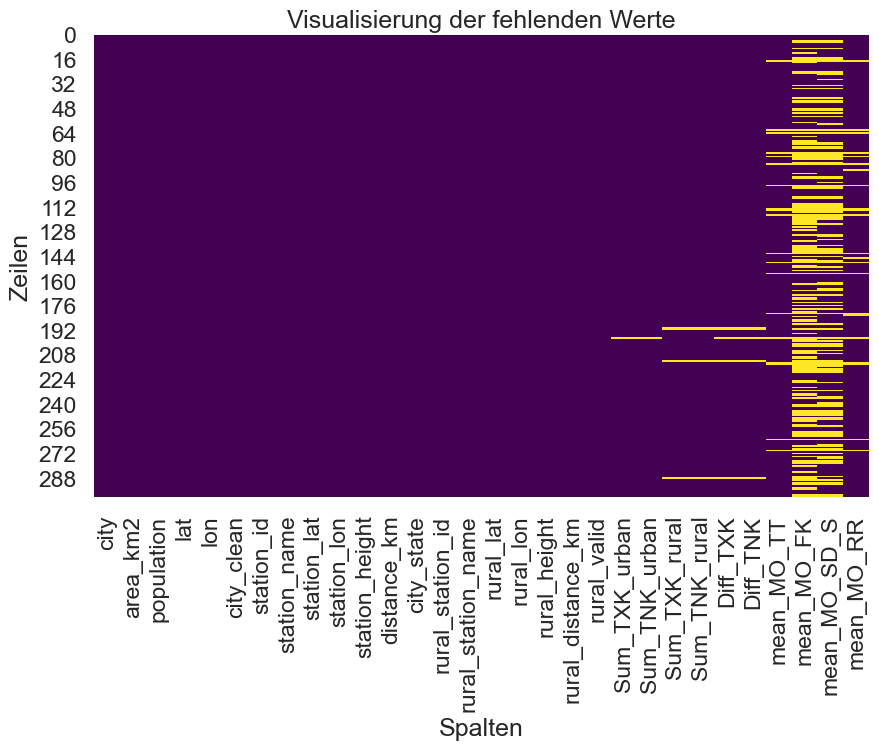

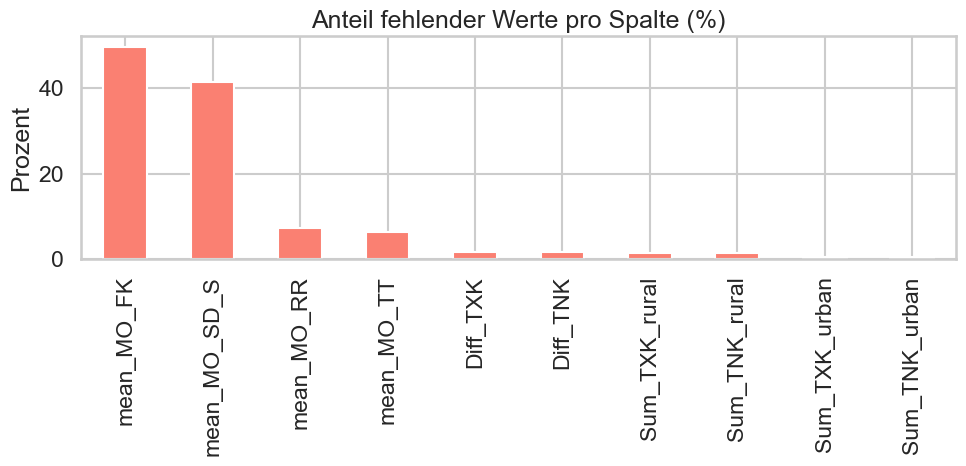

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = r"C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt\uhi_dwd_merged_V2.xlsx"   # Passe den Pfad ggf. an
df = pd.read_excel(file_path)


print(df.shape)
print(df.info())

# Anzahl und Anteil fehlender Werte pro Spalte
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Fehlende Werte': missing_counts,
    'Anteil (%)': missing_percent.round(2)
})

print("\n=== Fehlende Werte pro Spalte ===")
print(missing_df)

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Visualisierung der fehlenden Werte")
plt.xlabel("Spalten")
plt.ylabel("Zeilen")
plt.savefig(directory_images+"\\missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

# Balkendiagramm der Anteile fehlender Werte
plt.figure(figsize=(10,5))
missing_percent[missing_percent > 0].plot(kind='bar', color='salmon')
plt.title("Anteil fehlender Werte pro Spalte (%)")
plt.ylabel("Prozent")
plt.tight_layout()
plt.savefig(directory_images+"\\missing_values_percent.png", dpi=300, bbox_inches="tight")
plt.show()


Fehlende Werte auffüllen:

In [ ]:
import pandas as pd
from geopy.distance import geodesic
import numpy as np

df_filled = df.copy()


cols_to_fill = ["mean_MO_TT", "mean_MO_FK", "mean_MO_SD_S", "mean_MO_RR"]

# Höhen-Toleranz
height_tolerance = 50

# Funktion, um für eine Station die nächstgelegene mit ähnlicher Höhe zu finden
def find_nearest_station_with_data(lat, lon, height, target_col):
    # Filtere Stationen mit vorhandenem Wert
    available = df_filled[df_filled[target_col].notna()]
    
    # Filtere nach ähnlicher Höhe
    similar_height = available[
        (available["station_height"] >= height - height_tolerance) &
        (available["station_height"] <= height + height_tolerance)
    ]
    
    # Falls keine Station ähnliche Höhe hat, nimm alle
    if similar_height.empty:
        similar_height = available
    
    # Berechne Entfernungen (geodesic)
    similar_height["distance"] = similar_height.apply(
        lambda row: geodesic((lat, lon), (row["station_lat"], row["station_lon"])).km, axis=1
    )
    
    # Gib den Wert der nächstgelegenen Station zurück
    nearest = similar_height.loc[similar_height["distance"].idxmin()]
    return nearest[target_col]

# Fehlende Werte für jede relevante Spalte auffüllen
for col in cols_to_fill:
    print(f"Fülle fehlende Werte in {col} ...")
    missing_idx = df_filled[df_filled[col].isna()].index
    for i in missing_idx:
        row = df_filled.loc[i]
        filled_value = find_nearest_station_with_data(row["station_lat"], row["station_lon"], row["station_height"], col)
        df_filled.at[i, col] = filled_value



Fülle fehlende Werte in mean_MO_TT ...
Fülle fehlende Werte in mean_MO_FK ...


C:\Users\jetmi\AppData\Local\Temp\ipykernel_28808\3458129835.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\jetmi\AppData\Local\Temp\ipykernel_28808\3458129835.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\jetmi\AppData\Local\Temp\ipykernel_28808\3458129835.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

Fülle fehlende Werte in mean_MO_SD_S ...


C:\Users\jetmi\AppData\Local\Temp\ipykernel_28808\3458129835.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\jetmi\AppData\Local\Temp\ipykernel_28808\3458129835.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\jetmi\AppData\Local\Temp\ipykernel_28808\3458129835.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

Fülle fehlende Werte in mean_MO_RR ...
Auffüllen abgeschlossen.


C:\Users\jetmi\AppData\Local\Temp\ipykernel_28808\3458129835.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\jetmi\AppData\Local\Temp\ipykernel_28808\3458129835.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\jetmi\AppData\Local\Temp\ipykernel_28808\3458129835.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

In [137]:
print("=== Überblick ===")
print(df_filled.shape)
print(df_filled.info())

import pandas as pd

# Zeilen entfernen, bei denen die Zielvariablen fehlen
df_cleaned = df_filled.dropna(subset=["Diff_TXK", "Diff_TNK"]).reset_index(drop=True)

# Bereinigte Tabelle speichern
output_path = r"C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt\bereinigte_DS_Tabelle_V2.xlsx"
df_cleaned.to_excel(output_path, index=False)

print("Bereinigung abgeschlossen.")
print(f"Datei gespeichert unter: {output_path}")



=== Überblick ===
(300, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                300 non-null    object 
 1   area_km2            300 non-null    float64
 2   population          300 non-null    int64  
 3   lat                 300 non-null    float64
 4   lon                 300 non-null    float64
 5   city_clean          300 non-null    object 
 6   station_id          300 non-null    int64  
 7   station_name        300 non-null    object 
 8   station_lat         300 non-null    float64
 9   station_lon         300 non-null    float64
 10  station_height      300 non-null    int64  
 11  distance_km         300 non-null    float64
 12  city_state          300 non-null    object 
 13  rural_station_id    300 non-null    int64  
 14  rural_station_name  300 non-null    object 
 15  rural_lat           300 non-n

Filterung der Daten:
1) Kein Höhenunterschied > 200m
2) Stadtstation muss auch wirklich in der Stadt liegen

In [ ]:
import pandas as pd

# Ausgangsbasis: das bereinigte DataFrame mit allen Städten
df_filtered = df_cleaned.copy()


if "height_diff_m" not in df_filtered.columns:
    df_filtered["height_diff_m"] = (
        df_filtered["station_height"] - df_filtered["rural_height"]
    ).abs()

# Filter anwenden
df_filtered = df_filtered[df_filtered["height_diff_m"] < 200]


df_filtered = df_filtered[
    df_filtered.apply(
        lambda row: str(row["city_clean"]).lower() in str(row["station_name"]).lower(),
        axis=1
    )
]


df_filtered = df_filtered.reset_index(drop=True)

print(f"Nach den Filtern verbleibende Städte: {len(df_filtered)}")
df_filtered.head()


# Sicherstellen, dass die Spalte height_diff_m vorhanden ist
if "height_diff_m" not in df_cleaned.columns:
    df_cleaned["height_diff_m"] = (
        df_cleaned["station_height"] - df_cleaned["rural_height"]
    ).abs()

# 1) Vergleich der Stadtlisten vor und nach der Filterung
alle_staedte = set(df_cleaned["city_clean"].unique())
gefilterte_staedte = set(df_filtered["city_clean"].unique())

# Städte, die ausgeschlossen wurden
ausgeschlossene_staedte = sorted(list(alle_staedte - gefilterte_staedte))

print(f"Anzahl ausgeschlossener Städte: {len(ausgeschlossene_staedte)}")
print("\nBeispiele der ausgeschlossenen Städte:")
print(ausgeschlossene_staedte[:20])  # zeigt die ersten 20

# 2) Detailtabelle der ausgeschlossenen Städte
df_excluded = df_cleaned[df_cleaned["city_clean"].isin(ausgeschlossene_staedte)].copy()

# Übersicht der wichtigsten Infos
print("\nBeispielhafte ausgeschlossene Einträge:")
print(
    df_excluded[
        ["city_clean", "station_name", "station_height", "rural_height", "height_diff_m"]
    ].head()
)

output_path = directory+"\\ausgeschlossene_staedte_V2.xlsx"
df_excluded.to_excel(output_path, index=False)
print(f"\nDatei mit ausgeschlossenen Städten gespeichert unter: {output_path}")


df_filtered.to_excel(directory+"\\clean_cities_V2.xlsx",index=False)




Nach den Filtern verbleibende Städte: 72
Anzahl ausgeschlossener Städte: 223

Beispiele der ausgeschlossenen Städte:
['Aalen', 'Ahlen', 'Albstadt', 'Alsdorf', 'Ansbach', 'Arnsberg', 'Aschaffenburg', 'Aurich', 'Backnang', 'Bad Homburg v. d. Höhe', 'Bad Kreuznach', 'Bad Oeynhausen', 'Bad Salzuflen', 'Baden-Baden', 'Bamberg', 'Bayreuth', 'Bensheim', 'Bergheim', 'Bergisch Gladbach', 'Bergkamen']

Beispielhafte ausgeschlossene Einträge:
           city_clean            station_name  station_height  rural_height  \
3                Köln          Köln-Stammheim              43           350   
4   Frankfurt am Main  Frankfurt/Main-Westend             121           216   
8            Dortmund       Waltrop-Abdinghof              60            85   
12           Nürnberg                Nürnberg             314           522   
16          Wuppertal               Wuppertal             327            37   

    height_diff_m  
3             307  
4              95  
8              25  
12       

In [ ]:
# ================================================================
#  Explorative Analyse der Temperaturdifferenzen
# ================================================================

import plotly.express as px
import pandas as pd

file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"

# Excel-Datei korrekt einlesen
df = pd.read_excel(file_path)

# 1) Auswahl der Städte (z. B. die 150 größten nach Bevölkerung)
if "population" in df.columns:
    df = df.nlargest(100, "population")


# 2) Daten bereinigen und vorbereiten
df = df.dropna(subset=["station_lat", "station_lon", "Sum_TXK_urban"]).copy()
max_abs = df["Sum_TXK_urban"].abs().max()
min_abs = df["Sum_TXK_urban"].abs().min()


hover_cols = {
    "Sum_TXK_urban": True,
    "Sum_TNK_urban": True,
    "station_name": True
}
if "station_height" in df.columns:
    hover_cols["station_height"] = True


fig = px.scatter_mapbox(
    df,
    lat="station_lat",
    lon="station_lon",
    color="Sum_TXK_urban",
    color_continuous_scale=[
        (0.0, "blue"),   # Land heißer als Stadt
        (0.5, "white"),  # Neutral
        (1.0, "red")     # Stadt heißer als Land
    ],
    range_color=[0,max_abs],
    hover_name="city_clean",
    hover_data=hover_cols,
    zoom=5,
    height=800,
    opacity=0.8,
    title="Kummlative Anzahl der Hitzetage in deutschen Städten (2019-2024)"
)

fig.update_traces(marker=dict(size=22))

# Layout anpassen
fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    coloraxis_colorbar=dict(
        title=" ",
        tickvals=[max_abs,0],
        ticktext=[f"{max_abs:.1f}","0"]
    ),
    font=dict(size=14)
)

fig.show()


In [ ]:
# ================================================================
#  Explorative Analyse der Temperaturdifferenzen
# ================================================================

import plotly.express as px
import pandas as pd

file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"

df = pd.read_excel(file_path)

# 1) Auswahl der Städte (z. B. die 150 größten nach Bevölkerung)
if "population" in df.columns:
    df = df.nlargest(100, "population")


# 2) Daten bereinigen und vorbereiten
df = df.dropna(subset=["station_lat", "station_lon", "Sum_TNK_urban"]).copy()
max_abs = df["Sum_TNK_urban"].abs().max()

hover_cols = {
    "Sum_TNK_urban": True,
    "Sum_TXK_urban": True,
    "station_name": True
}
if "station_height" in df.columns:
    hover_cols["station_height"] = True

fig = px.scatter_mapbox(
    df,
    lat="station_lat",
    lon="station_lon",
    color="Sum_TNK_urban",
    color_continuous_scale=[
        (0.0, "white"),  # Neutral
        (1.0, "red")     # Stadt heißer als Land
    ],
    range_color=[0, max_abs],
    hover_name="city_clean",
    hover_data=hover_cols,
    zoom=5,
    height=800,
    opacity=0.8,
    title="Kummlative Anzahl der Tropennächte in deutschen Städten (2019-2024)"
)

fig.update_traces(marker=dict(size=22))

fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    coloraxis_colorbar=dict(
        title=" ",
        tickvals=[max_abs, 0],
        ticktext=[f"{max_abs:.1f}", "0"]
    ),
    font=dict(size=14)
)

fig.show()


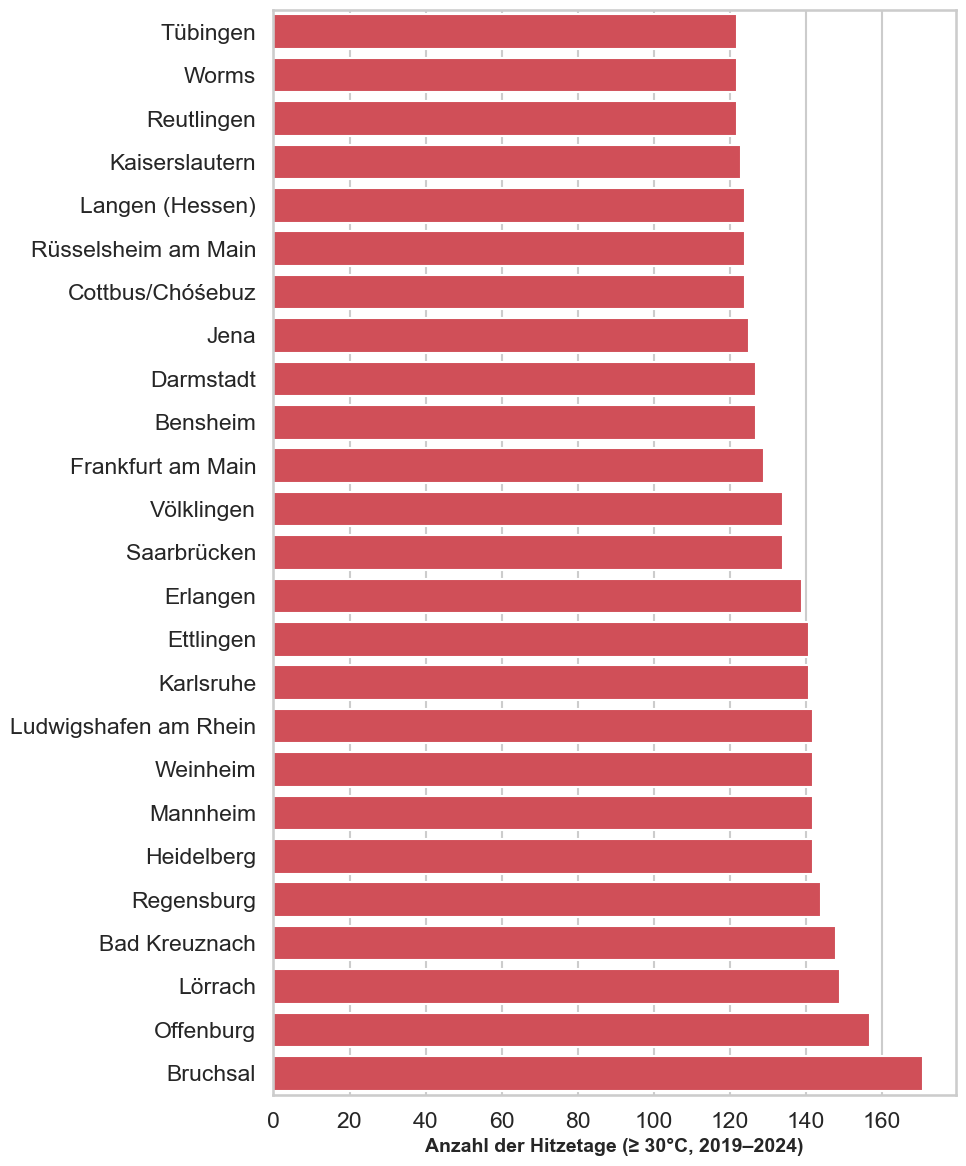

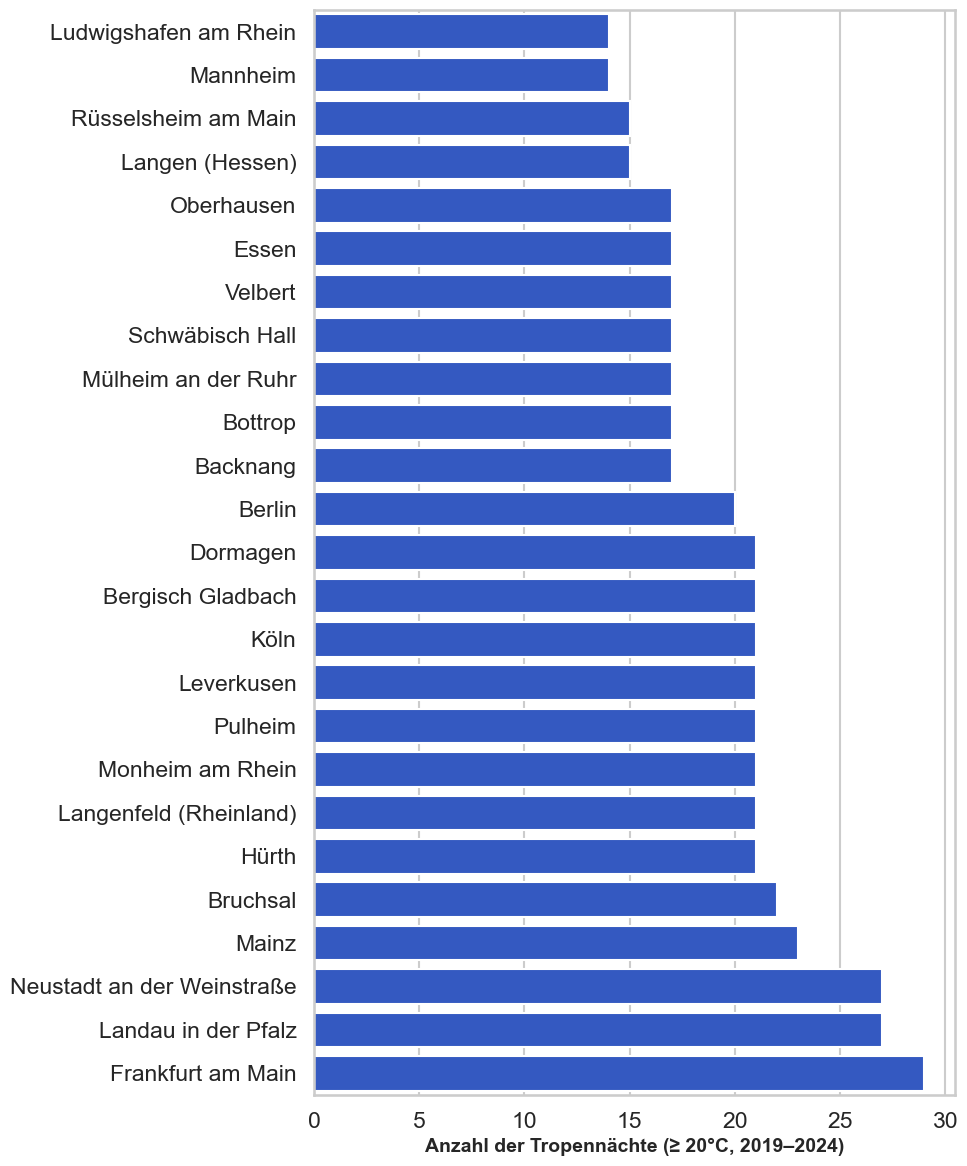

✅ Diagramme gespeichert unter:
C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt\images\top50_hitzetage_staedte.png
C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt\images\top50_tropennaechte_staedte.png


In [ ]:
# ================================================================
# Top Städte mit den meisten Hitzetagen und Tropennächten (2019–2024)
# ================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ------------------------------------------------
# 1) Daten laden
# ------------------------------------------------
file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"
df = pd.read_excel(file_path)

# ------------------------------------------------
# 2) Nur relevante Spalten behalten
# ------------------------------------------------
cols = ["city_clean", "Sum_TXK_urban", "Sum_TNK_urban"]
df = df[cols].dropna()

# ------------------------------------------------
# 3) Top Städte – Hitzetage
# ------------------------------------------------
top_hot = df.nlargest(25, "Sum_TXK_urban").sort_values("Sum_TXK_urban", ascending=True)

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(10, 12))

sns.barplot(
    data=top_hot,
    x="Sum_TXK_urban",
    y="city_clean",
    color="#e63946"  # Einheitliches kräftiges Rot
)

plt.xlabel("Anzahl der Hitzetage (≥ 30°C, 2019–2024)", fontsize=14, weight="bold")
plt.ylabel("")
#plt.title("Top 50 Städte mit den meisten Hitzetagen", fontsize=16, weight="bold")
plt.tight_layout()

output_path_1 = os.path.join(directory_images, "top50_hitzetage_staedte.png")
plt.savefig(output_path_1, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------
# 4) Top Städte – Tropennächte
# ------------------------------------------------
top_tropical = df.nlargest(25, "Sum_TNK_urban").sort_values("Sum_TNK_urban", ascending=True)

plt.figure(figsize=(10, 12))

sns.barplot(
    data=top_tropical,
    x="Sum_TNK_urban",
    y="city_clean",
    color="#1d4ed8"  # Einheitliches kräftiges Blau
)

plt.xlabel("Anzahl der Tropennächte (≥ 20°C, 2019–2024)", fontsize=14, weight="bold")
plt.ylabel("")
#plt.title("Top 25 Städte mit den meisten Tropennächten", fontsize=16, weight="bold")
plt.tight_layout()

output_path_2 = os.path.join(directory_images, "top50_tropennaechte_staedte.png")
plt.savefig(output_path_2, dpi=300, bbox_inches="tight")
plt.show()



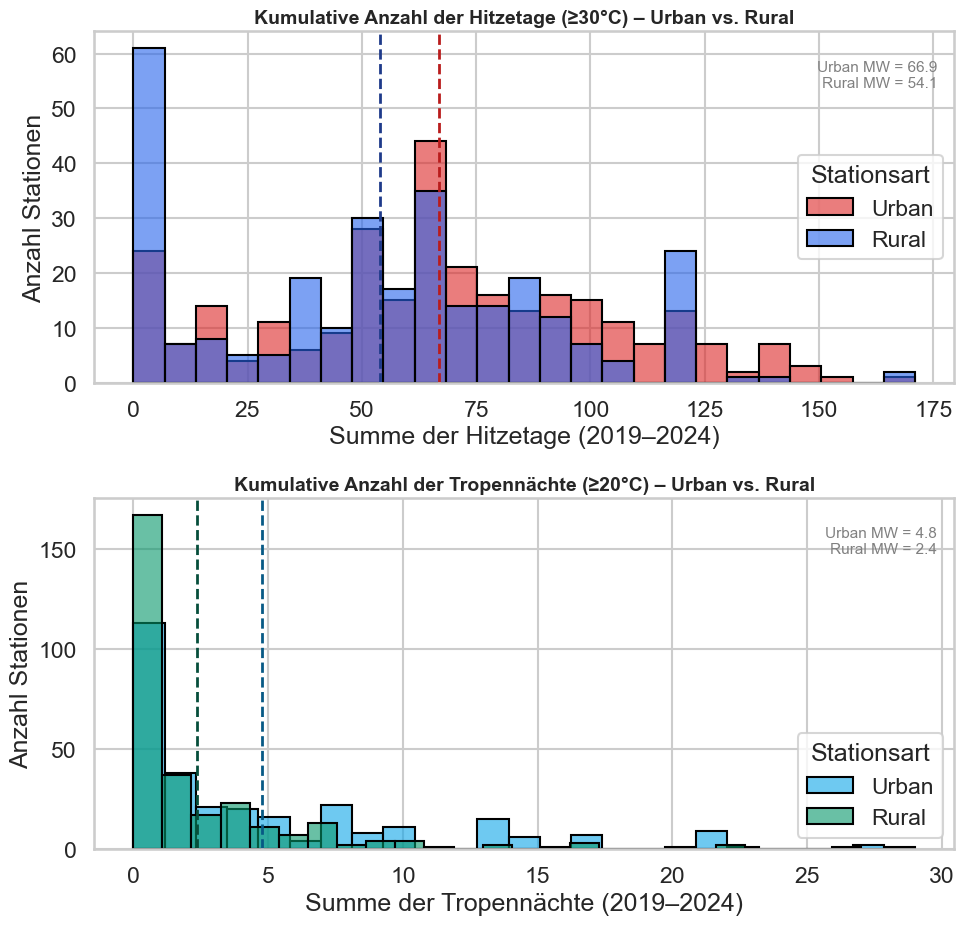

In [ ]:
# ================================================================
# Vergleich von urbanen & ländlichen Stationen (2019–2024)
# ================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------
# 1) Stil & Daten laden
# ------------------------------------------
sns.set_theme(style="whitegrid", context="talk")

file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"
df = pd.read_excel(file_path)

# Nur relevante Spalten
cols = ["Sum_TXK_urban", "Sum_TXK_rural", "Sum_TNK_urban", "Sum_TNK_rural"]
df = df[cols].dropna()

# ------------------------------------------
# 2) Statistische Kennzahlen berechnen
# ------------------------------------------
def get_stats(series):
    return {
        "mean": series.mean(),
        "median": series.median(),
        "std": series.std()
    }

stats = {
    "Sum_TXK_urban": get_stats(df["Sum_TXK_urban"]),
    "Sum_TXK_rural": get_stats(df["Sum_TXK_rural"]),
    "Sum_TNK_urban": get_stats(df["Sum_TNK_urban"]),
    "Sum_TNK_rural": get_stats(df["Sum_TNK_rural"])
}

# ------------------------------------------
# 3) Figure mit 2 Subplots (Hitzetage + Tropennächte)
# ------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=False)

# Gemeinsame Parameter
common_kws = dict(bins=25, edgecolor="black", alpha=0.6)

# ------------------------------------------
#  Plot 1: Hitzetage (urban vs. rural)
# ------------------------------------------
sns.histplot(
    df["Sum_TXK_urban"], color="#dc2626", label="Urban", ax=axes[0], **common_kws
)
sns.histplot(
    df["Sum_TXK_rural"], color="#2563eb", label="Rural", ax=axes[0], **common_kws
)

# Mittelwerte markieren
axes[0].axvline(stats["Sum_TXK_urban"]["mean"], color="#b91c1c", linestyle="--", lw=2)
axes[0].axvline(stats["Sum_TXK_rural"]["mean"], color="#1e3a8a", linestyle="--", lw=2)

axes[0].set_title("Kumulative Anzahl der Hitzetage (≥30°C) – Urban vs. Rural", fontsize=14, weight="bold")
axes[0].set_xlabel("Summe der Hitzetage (2019–2024)")
axes[0].set_ylabel("Anzahl Stationen")
axes[0].legend(title="Stationsart")
axes[0].text(
    0.98, 0.92,
    f"Urban MW = {stats['Sum_TXK_urban']['mean']:.1f}\nRural MW = {stats['Sum_TXK_rural']['mean']:.1f}",
    transform=axes[0].transAxes,
    ha="right", va="top", fontsize=11, color="gray"
)

# ------------------------------------------
# Plot 2: Tropennächte (urban vs. rural)
# ------------------------------------------
sns.histplot(
    df["Sum_TNK_urban"], color="#0ea5e9", label="Urban", ax=axes[1], **common_kws
)
sns.histplot(
    df["Sum_TNK_rural"], color="#059669", label="Rural", ax=axes[1], **common_kws
)

# Mittelwerte markieren
axes[1].axvline(stats["Sum_TNK_urban"]["mean"], color="#075985", linestyle="--", lw=2)
axes[1].axvline(stats["Sum_TNK_rural"]["mean"], color="#064e3b", linestyle="--", lw=2)

axes[1].set_title("Kumulative Anzahl der Tropennächte (≥20°C) – Urban vs. Rural", fontsize=14, weight="bold")
axes[1].set_xlabel("Summe der Tropennächte (2019–2024)")
axes[1].set_ylabel("Anzahl Stationen")
axes[1].legend(title="Stationsart")
axes[1].text(
    0.98, 0.92,
    f"Urban MW = {stats['Sum_TNK_urban']['mean']:.1f}\nRural MW = {stats['Sum_TNK_rural']['mean']:.1f}",
    transform=axes[1].transAxes,
    ha="right", va="top", fontsize=11, color="gray"
)

# ------------------------------------------
# 4) Gesamt-Titel & Layout
# ------------------------------------------

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ------------------------------------------
# 5) Optional: Speichern
# ------------------------------------------
plt.savefig(
    directory_images + r"\uhi_histogramme_urban_vs_rural_2019_2024.png",
    dpi=300, bbox_inches="tight"
)
plt.show()


In [142]:
# ================================================================
# 👥 Gesamtbevölkerung der 100 größten Städte berechnen
# ================================================================

import pandas as pd

# Datei laden
file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"
df = pd.read_excel(file_path)

# Sicherstellen, dass die Spalte 'population' existiert
if "population" not in df.columns:
    raise KeyError("Die Spalte 'population' fehlt in der Tabelle.")

# Datentyp sicherstellen
df["population"] = pd.to_numeric(df["population"], errors="coerce")

# Nur gültige Werte berücksichtigen
df = df.dropna(subset=["population"])

# Top 100 Städte nach Bevölkerung auswählen
df_top100 = df.nlargest(100, "population")

# Summe der Einwohner berechnen
summe_einwohner = df_top100["population"].sum()

print(f"Gesamtbevölkerung der 100 größten Städte: {summe_einwohner:,.0f} Einwohner")


Gesamtbevölkerung der 100 größten Städte: 28,615,014 Einwohner


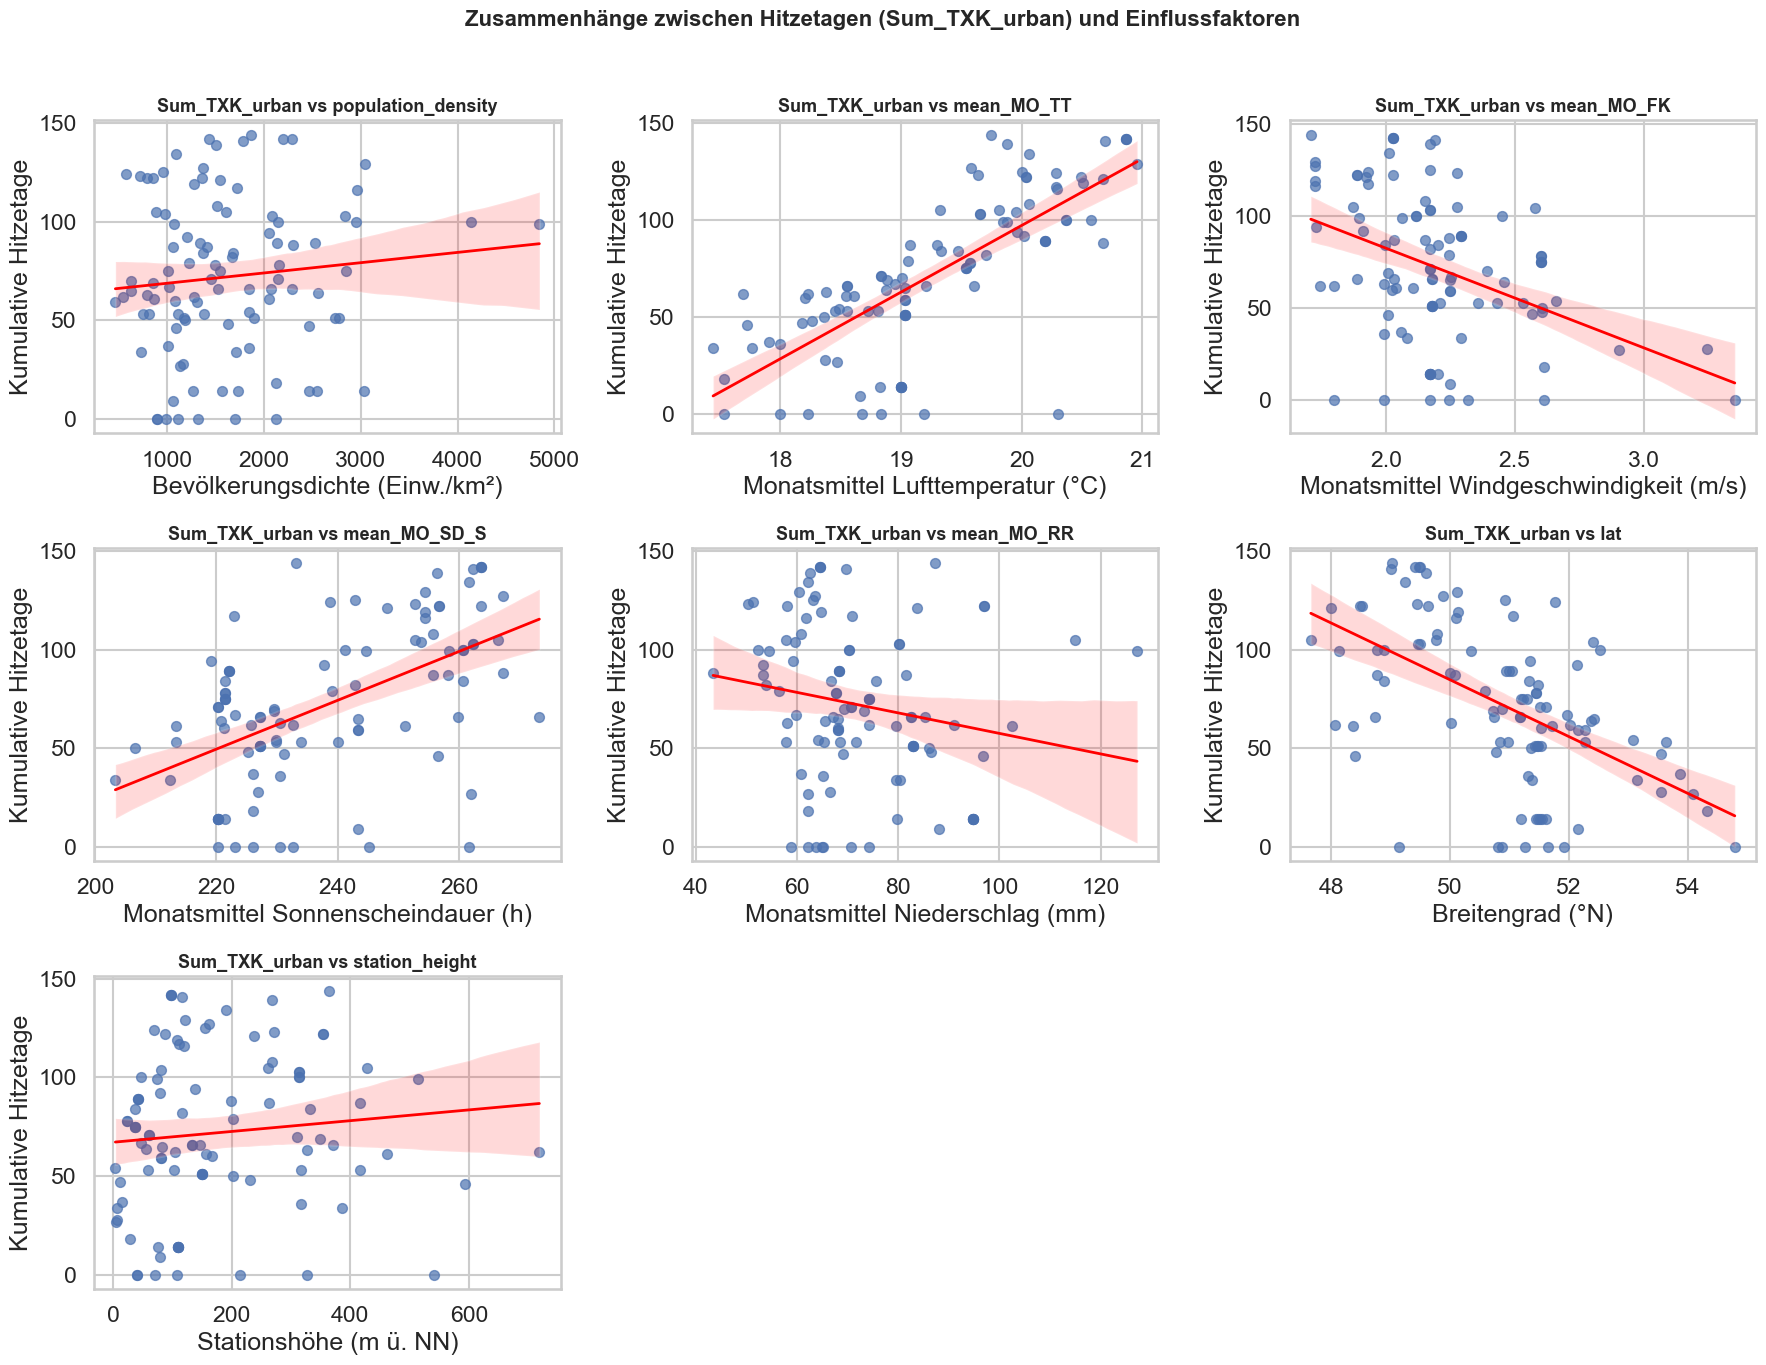

In [144]:
# ================================================================
# Explorative Analyse: Einflussfaktoren auf Hitzetage in Städten
# ================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1) Daten laden und vorbereiten
# -------------------------------------------------
file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"
df = pd.read_excel(file_path)
df = df.head(100)

# Nur relevante Spalten behalten
relevant_cols = [
    "city_clean", "population", "area_km2", "lat",
    "mean_MO_TT", "mean_MO_FK", "mean_MO_SD_S", "mean_MO_RR",
    "station_height", "Sum_TXK_urban"
]
df = df[relevant_cols].dropna()

# Bevölkerungsdichte berechnen (Einwohner pro km²)
df["population_density"] = df["population"] / df["area_km2"]

# -------------------------------------------------
# 2) Variablen definieren (mit Achsenlabels)
# -------------------------------------------------
predictors = {
    "population_density": "Bevölkerungsdichte (Einw./km²)",
    "mean_MO_TT": "Monatsmittel Lufttemperatur (°C)",
    "mean_MO_FK": "Monatsmittel Windgeschwindigkeit (m/s)",
    "mean_MO_SD_S": "Monatsmittel Sonnenscheindauer (h)",
    "mean_MO_RR": "Monatsmittel Niederschlag (mm)",
    "lat": "Breitengrad (°N)",
    "station_height": "Stationshöhe (m ü. NN)"
}

# -------------------------------------------------
# 3) Scatterplots mit Regressionslinie
# -------------------------------------------------
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (x, xlabel) in enumerate(predictors.items()):
    sns.regplot(
        data=df,
        x=x, y="Sum_TXK_urban",
        scatter_kws={"alpha": 0.7, "s": 50},
        line_kws={"color": "red", "lw": 2},
        ax=axes[i]
    )
    axes[i].set_title(f"Sum_TXK_urban vs {x}", fontsize=13, weight="bold")  # Original-Spaltenname im Titel
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel("Kumulative Hitzetage")

# Leere Subplots ausblenden (wenn weniger als 9)
for j in range(len(predictors), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Zusammenhänge zwischen Hitzetagen (Sum_TXK_urban) und Einflussfaktoren",
    fontsize=16, weight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Optional: Speichern
plt.savefig(
    directory_images + r"\uhi_scatter_influences_TXK_urban_original_titles.png",
    dpi=300, bbox_inches="tight"
)

plt.show()


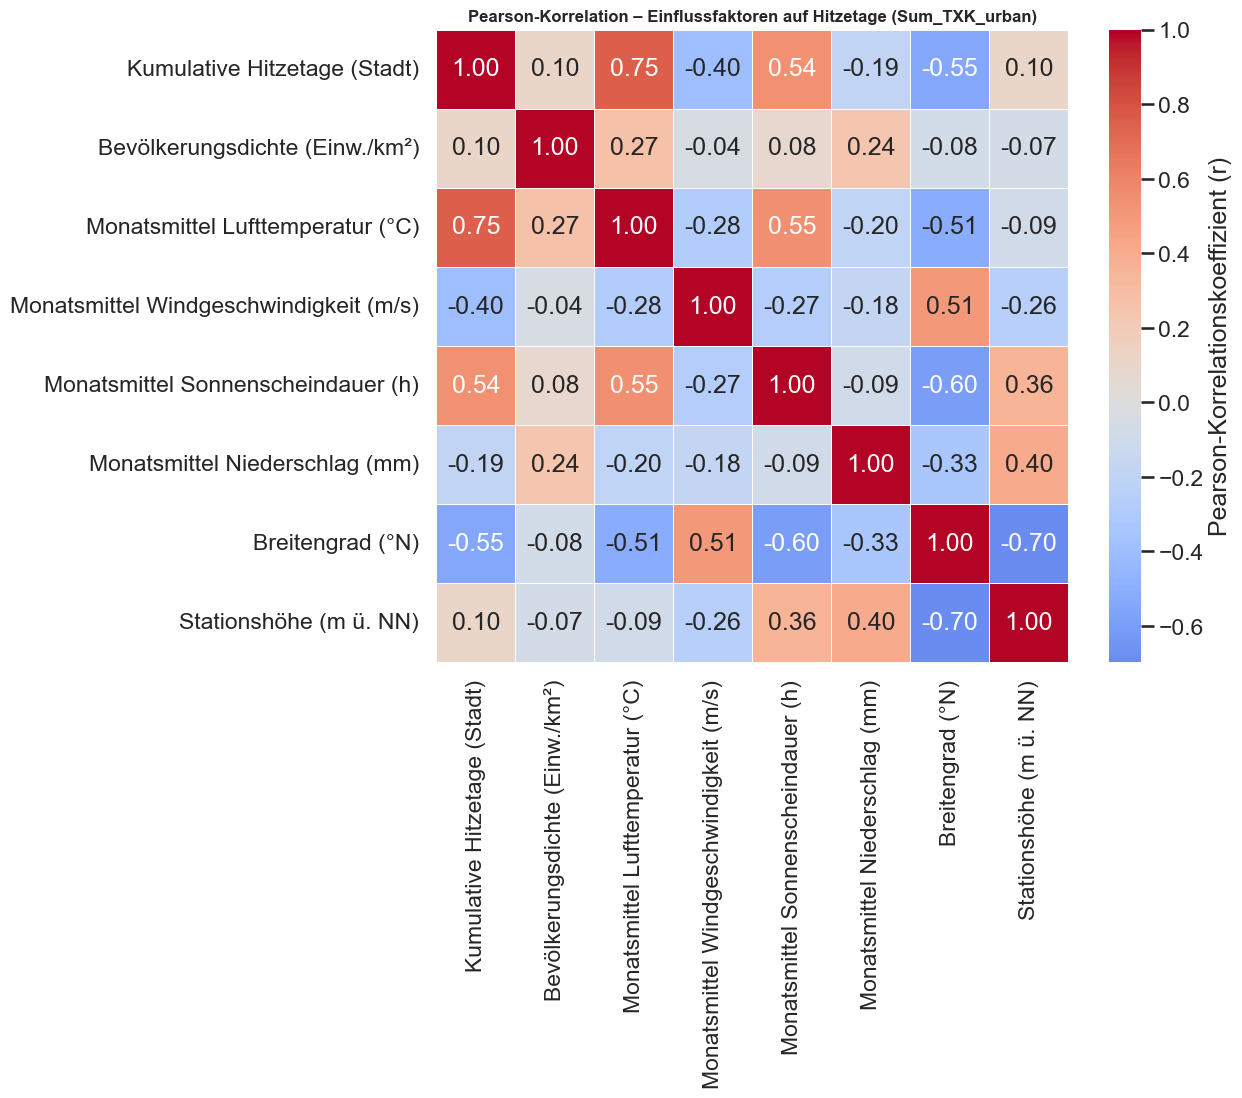

In [ ]:
# ====================
# Korrelationsanalyse 
# ===================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1) Daten laden und vorbereiten
# -------------------------------------------------
file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"
df = pd.read_excel(file_path)
df = df.head(100)

# Nur relevante Spalten behalten
relevant_cols = [
    "Sum_TXK_urban",       # Zielvariable
    "population", "area_km2",
    "mean_MO_TT", "mean_MO_FK", "mean_MO_SD_S", "mean_MO_RR",
    "lat", "station_height"
]
df = df[relevant_cols].dropna()

# Bevölkerungsdichte berechnen
df["population_density"] = df["population"] / df["area_km2"]

# -------------------------------------------------
# 2) Beschriftungen für die Achsen mit Einheiten
# -------------------------------------------------
rename_labels = {
    "Sum_TXK_urban": "Kumulative Hitzetage (Stadt)",
    "population_density": "Bevölkerungsdichte (Einw./km²)",
    "mean_MO_TT": "Monatsmittel Lufttemperatur (°C)",
    "mean_MO_FK": "Monatsmittel Windgeschwindigkeit (m/s)",
    "mean_MO_SD_S": "Monatsmittel Sonnenscheindauer (h)",
    "mean_MO_RR": "Monatsmittel Niederschlag (mm)",
    "lat": "Breitengrad (°N)",
    "station_height": "Stationshöhe (m ü. NN)"
}

# -------------------------------------------------
# 3) Korrelationsmatrix berechnen (Pearson)
# -------------------------------------------------
corr_cols = list(rename_labels.keys())
corr_matrix = df[corr_cols].corr(method="pearson")

# Spaltennamen für Darstellung umbenennen
corr_matrix = corr_matrix.rename(index=rename_labels, columns=rename_labels)

# -------------------------------------------------
# 4) Heatmap visualisieren
# -------------------------------------------------
sns.set_theme(style="white", context="talk")

plt.figure(figsize=(13, 11))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, square=True,
    cbar_kws={"label": "Pearson-Korrelationskoeffizient (r)"}
)

plt.title("Pearson-Korrelation – Einflussfaktoren auf Hitzetage (Sum_TXK_urban)", fontsize=12, weight="bold")
plt.tight_layout()

plt.savefig(
    directory_images + r"\uhi_correlation_matrix_pearson_TXK_urban_labeled.png",
    dpi=300, bbox_inches="tight"
)

plt.show()



In [155]:
# ================================================================
# DWD-Klimadaten 2019–2024: Visualisierung auf Deutschlandkarte
# ================================================================

import pandas as pd
import plotly.express as px

# -----------------------------------------
# 1) Daten laden
# -----------------------------------------
file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"
df = pd.read_excel(file_path)

# Sicherstellen, dass alle relevanten Spalten vorhanden sind
climate_vars = ["mean_MO_TT", "mean_MO_FK", "mean_MO_SD_S", "mean_MO_RR"]
df = df.dropna(subset=["station_lat", "station_lon"] + climate_vars)

# -----------------------------------------
# 2) Spaltennamen → DWD-Beschreibungen mit Einheiten
# -----------------------------------------
climate_labels = {
    "mean_MO_TT": "Monatsmittel der Lufttemperatur [°C]",
    "mean_MO_FK": "Monatsmittel der Windgeschwindigkeit [m/s]",
    "mean_MO_SD_S": "Monatsmittel der Sonnenscheindauer [h]",
    "mean_MO_RR": "Monatsmittel der Niederschlagshöhe [mm]"
}

# -----------------------------------------
# 3) Interaktive Karte für jede Klimavariable
# -----------------------------------------
for col in climate_vars:
    fig = px.scatter_mapbox(
        df,
        lat="station_lat",
        lon="station_lon",
        color=col,
        hover_name="city_clean",
        hover_data={
            "station_name": True,
            "station_height": True,
            col: True
        },
        color_continuous_scale="RdYlBu_r",  # Blau = niedrig, Rot = hoch
        zoom=5,
        height=800,
        title=f"{climate_labels[col]} (DWD-Daten 2019–2024)"
    )

    # Punkte vergrößern & Layout anpassen
    fig.update_traces(marker=dict(size=16, opacity=0.85))
    fig.update_layout(
        mapbox_style="open-street-map",
        margin={"r": 0, "t": 50, "l": 0, "b": 0},
        coloraxis_colorbar=dict(
            title=climate_labels[col],
            title_side="right",       # Titel rechts neben der Skala
            ticklen=4,
            ticks="outside"
        ),
        font=dict(size=14)
    )

    fig.show()


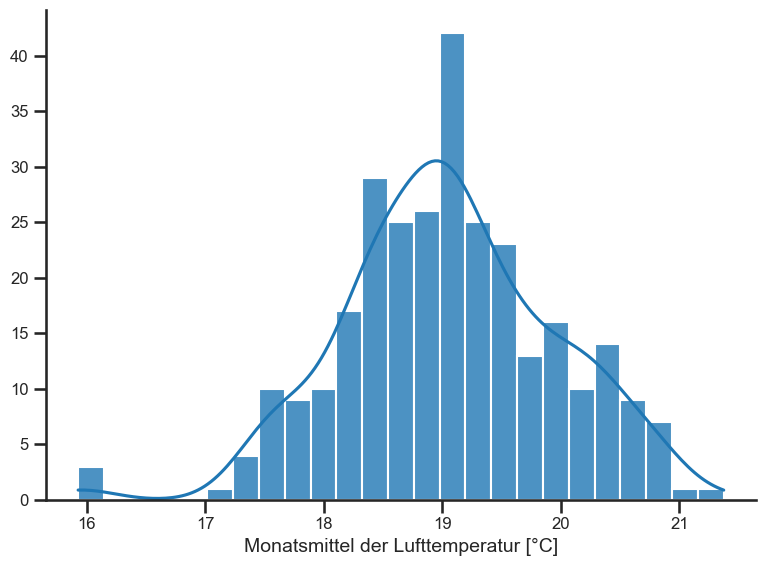

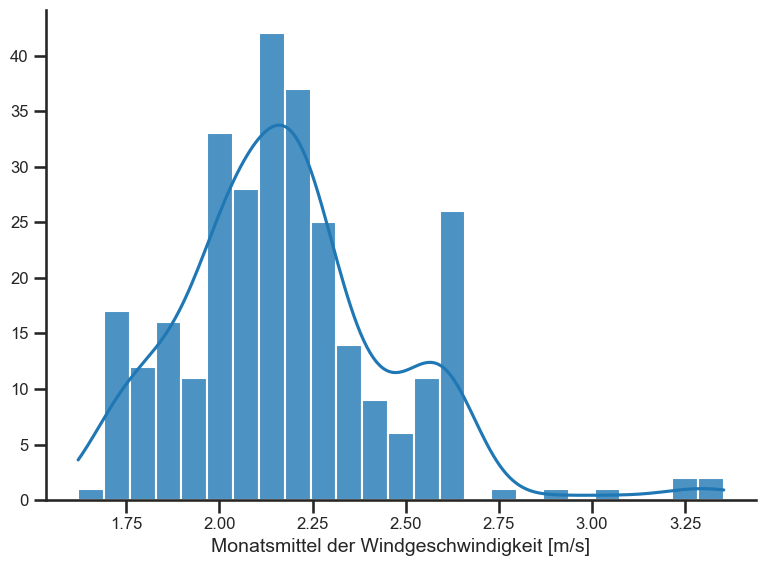

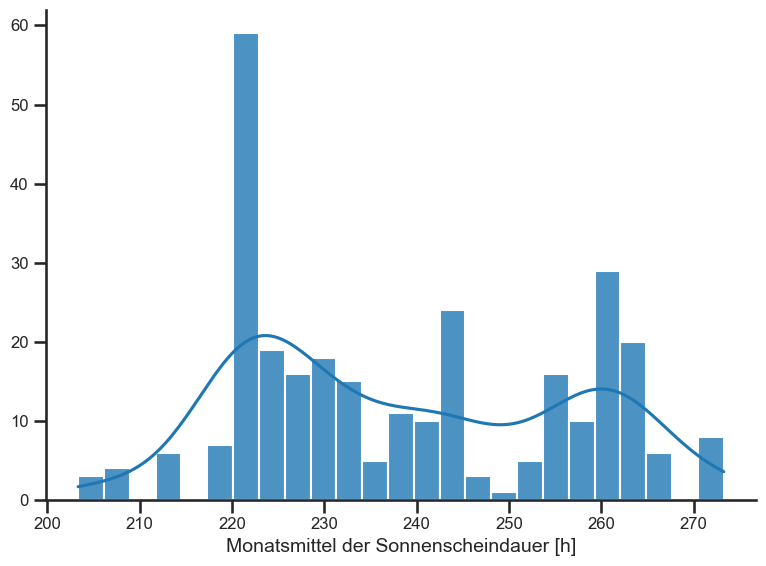

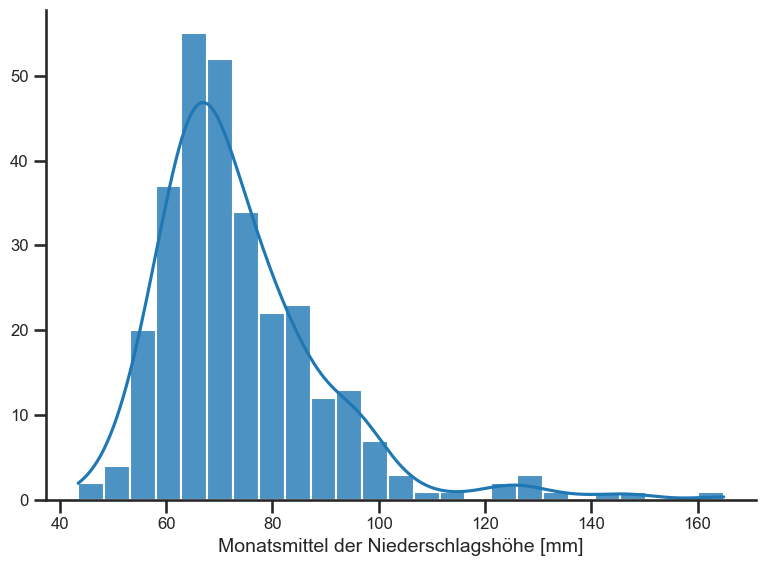

✅ Minimalistische Histogramme gespeichert unter:
C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt\images\climate_histograms_minimal


In [ ]:
# ================================================================
# DWD-Klimadaten – Minimalistische Histogramme (2019–2024)
# ================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ------------------------------------------------
# 1) Daten laden
# ------------------------------------------------
file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"
df = pd.read_excel(file_path)

# Relevante Spalten
climate_vars = ["mean_MO_TT", "mean_MO_FK", "mean_MO_SD_S", "mean_MO_RR"]
df = df.dropna(subset=climate_vars)

# ------------------------------------------------
# 2) DWD-Beschriftungen mit Einheiten
# ------------------------------------------------
climate_labels = {
    "mean_MO_TT": "Monatsmittel der Lufttemperatur [°C]",
    "mean_MO_FK": "Monatsmittel der Windgeschwindigkeit [m/s]",
    "mean_MO_SD_S": "Monatsmittel der Sonnenscheindauer [h]",
    "mean_MO_RR": "Monatsmittel der Niederschlagshöhe [mm]"
}

# Ausgabeordner
output_dir = directory_images + r"\climate_histograms_minimal"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------
# 3) Design: clean & minimalistisch
# ------------------------------------------------
sns.set_theme(style="ticks", context="talk")  # Keine Gitterlinien
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ------------------------------------------------
# 4) Histogramme erstellen
# ------------------------------------------------
for col in climate_vars:
    plt.figure(figsize=(8, 6))

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=25,
        color="#1f77b4",       # Blau (dezent)
        edgecolor=None,
        alpha=0.8
    )

    # Nur Achsenbeschriftungen, kein Titel
    plt.xlabel(climate_labels[col])
    plt.ylabel("")  # Y-Achse ohne Label für cleaner Look
    sns.despine()   # Entfernt oberen und rechten Rand

    plt.tight_layout()

    # Speichern
    filename = f"{col}_histogram_minimal.png"
    plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches="tight", transparent=True)
    plt.show()




=== Modell: Lineare Regression (ohne_Filter) ===
Anzahl der Städte: 295
R²:   0.545 ± 0.102
RMSE: 25.06 ± 3.91
MAE:  18.36 ± 2.66
📈 Diagramm gespeichert unter: C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt\images\linear_regression_cv_ohne_Filter.png


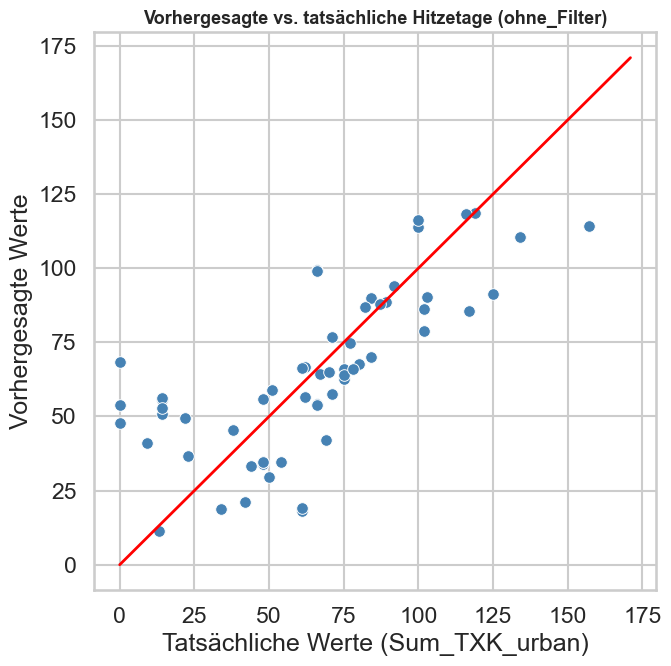


=== Modell: Lineare Regression (mit_Filter) ===
Anzahl der Städte: 247
R²:   0.792 ± 0.031
RMSE: 13.23 ± 0.63
MAE:  10.14 ± 0.49
📈 Diagramm gespeichert unter: C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt\images\linear_regression_cv_mit_Filter.png


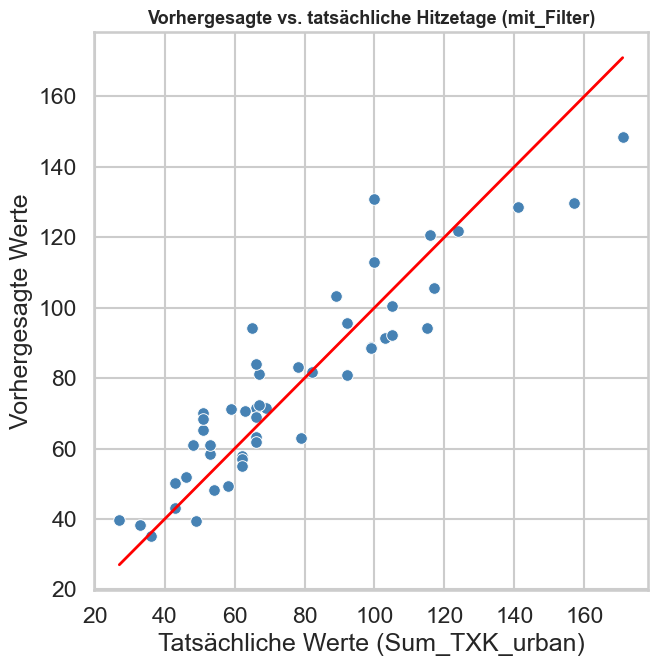

In [ ]:
# =====================================
# Lineare Regression mit & ohne Filter 
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# -------------------------------------------------
# 1) Daten laden und vorbereiten
# -------------------------------------------------
file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"
df_full = pd.read_excel(file_path)

# Relevante Spalten auswählen
features = [
    "population", "area_km2", "mean_MO_TT", "mean_MO_FK",
    "mean_MO_SD_S", "mean_MO_RR", "lat", "station_height"
]
target = "Sum_TXK_urban"

df_full = df_full[features + [target]].dropna()
df_full["population_density"] = df_full["population"] / df_full["area_km2"]

# Zwei Varianten des Datensatzes
datasets = {
    "ohne_Filter": df_full,
    "mit_Filter": df_full[df_full["Sum_TXK_urban"] > 25]
}

# -------------------------------------------------
# 2) Cross-Validation + Visualisierung für beide Varianten
# -------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

for name, df in datasets.items():
    print(f"\n=== Modell: Lineare Regression ({name}) ===")
    print(f"Anzahl der Städte: {len(df)}")

    X = df[[ 
        "population_density", "mean_MO_TT", "mean_MO_FK",
        "mean_MO_SD_S", "mean_MO_RR", "lat", "station_height"
    ]]
    y = df[target]

    # Pipeline: StandardScaler + Regression
    model = make_pipeline(StandardScaler(), LinearRegression())

    # Cross-Validation
    results = cross_validate(model, X, y, cv=5, scoring=scoring, return_train_score=False)

    # Ergebnisse
    r2_mean = np.mean(results["test_r2"])
    r2_std  = np.std(results["test_r2"])
    rmse_scores = -results["test_rmse"]
    mae_scores  = -results["test_mae"]

    print(f"R²:   {r2_mean:.3f} ± {r2_std:.3f}")
    print(f"RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
    print(f"MAE:  {mae_scores.mean():.2f} ± {mae_scores.std():.2f}")

    # -------------------------------------------------
    # 3) Visualisierung mit einfachem Train/Test Split
    # -------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    pipe = make_pipeline(StandardScaler(), LinearRegression())
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_test, y=y_pred, s=70, color="steelblue")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", lw=2)
    plt.title(f"Vorhergesagte vs. tatsächliche Hitzetage ({name})", fontsize=13, weight="bold")
    plt.xlabel("Tatsächliche Werte (Sum_TXK_urban)")
    plt.ylabel("Vorhergesagte Werte")
    plt.tight_layout()

    save_path = directory_images + fr"\linear_regression_cv_{name}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()



=== Polynomielle Regression (2. Ordnung) – ohne_Filter ===
Anzahl der Städte: 295
R²:   0.476 ± 0.031
RMSE: 27.06 ± 2.28
MAE:  19.00 ± 2.12
Testdaten (für Plot): R²=0.657, RMSE=20.525, MAE=16.026
📈 Diagramm gespeichert unter: C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt\images\polynomial_regression_degree2_TXK_urban_cv_ohne_Filter.png


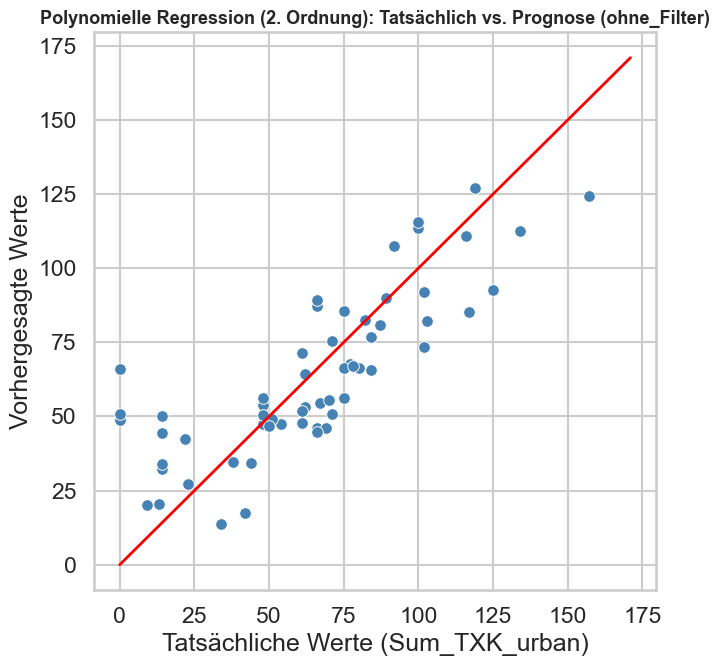


=== Polynomielle Regression (2. Ordnung) – mit_Filter ===
Anzahl der Städte: 247
R²:   0.787 ± 0.065
RMSE: 13.43 ± 2.74
MAE:  9.53 ± 1.45
Testdaten (für Plot): R²=0.869, RMSE=11.332, MAE=8.615
📈 Diagramm gespeichert unter: C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt\images\polynomial_regression_degree2_TXK_urban_cv_mit_Filter.png


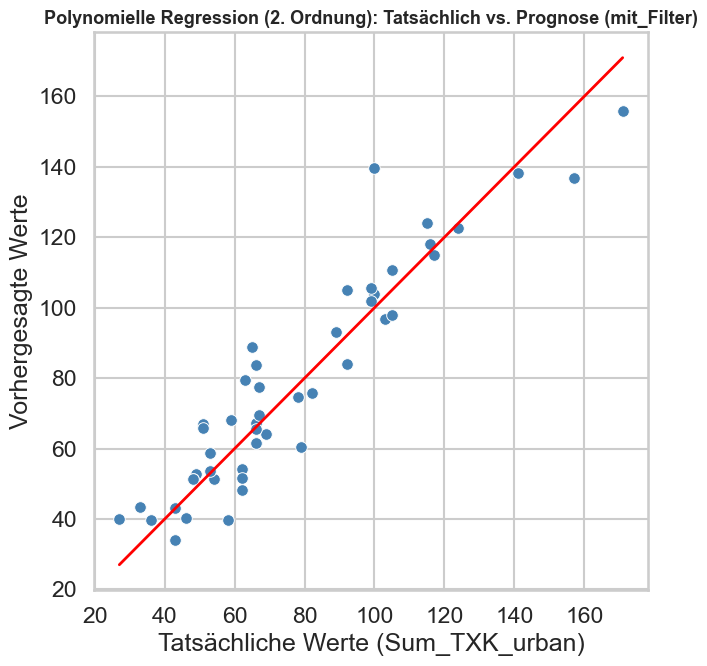

In [ ]:
# ================================================================
# Polynomielle Regression (2. Ordnung) mit & ohne Filter
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline

# -------------------------------------------------
# 1) Daten laden und vorbereiten
# -------------------------------------------------
file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"
df_full = pd.read_excel(file_path)

# Relevante Spalten
features = [
    "population", "area_km2", "mean_MO_TT", "mean_MO_FK",
    "mean_MO_SD_S", "mean_MO_RR", "lat", "station_height"
]
target = "Sum_TXK_urban"

df_full = df_full[features + [target]].dropna()
df_full["population_density"] = df_full["population"] / df_full["area_km2"]

# Zwei Varianten des Datensatzes
datasets = {
    "ohne_Filter": df_full,
    "mit_Filter": df_full[df_full["Sum_TXK_urban"] > 25]
}

# -------------------------------------------------
# 2) Modell, Scoring & Cross-Validation
# -------------------------------------------------
scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

for name, df in datasets.items():
    print(f"\n=== Polynomielle Regression (2. Ordnung) – {name} ===")
    print(f"Anzahl der Städte: {len(df)}")

    X = df[[ 
        "population_density", "mean_MO_TT", "mean_MO_FK",
        "mean_MO_SD_S", "mean_MO_RR", "lat", "station_height"
    ]]
    y = df[target]

    # Pipeline: PolynomialFeatures → StandardScaler → LinearRegression
    model = make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )

    # Cross-Validation
    results = cross_validate(model, X, y, cv=5, scoring=scoring, return_train_score=False)

    # Ergebnisse berechnen
    r2_mean = np.mean(results["test_r2"])
    r2_std = np.std(results["test_r2"])
    rmse_scores = -results["test_rmse"]
    mae_scores = -results["test_mae"]

    print(f"R²:   {r2_mean:.3f} ± {r2_std:.3f}")
    print(f"RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
    print(f"MAE:  {mae_scores.mean():.2f} ± {mae_scores.std():.2f}")

    # -------------------------------------------------
    # 3) Train/Test für Visualisierung
    # -------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Skalierung
    scaler = StandardScaler()
    X_train_poly_scaled = scaler.fit_transform(X_train_poly)
    X_test_poly_scaled = scaler.transform(X_test_poly)

    # Modell trainieren
    reg = LinearRegression()
    reg.fit(X_train_poly_scaled, y_train)
    y_pred = reg.predict(X_test_poly_scaled)

    # Einzelne Metriken für Plot
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"Testdaten (für Plot): R²={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")

    # -------------------------------------------------
    # 4) Visualisierung
    # -------------------------------------------------
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_test, y=y_pred, s=70, color="steelblue")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", lw=2)
    plt.title(f"Polynomielle Regression (2. Ordnung): Tatsächlich vs. Prognose ({name})", fontsize=13, weight="bold")
    plt.xlabel("Tatsächliche Werte (Sum_TXK_urban)")
    plt.ylabel("Vorhergesagte Werte")
    plt.tight_layout()

    # Bild speichern
    save_path = directory_images + fr"\polynomial_regression_degree2_TXK_urban_cv_{name}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()



=== Ridge & Lasso Regression – ohne_Filter ===
Anzahl der Städte: 295
=== Cross-Validation (5-fold) Ergebnisse ===
             Modell  R² (mean)  R² (std)  RMSE (mean)  RMSE (std)  MAE (mean)  \
0  Ridge Regression      0.544     0.096       25.105       3.702      18.160   
1  Lasso Regression      0.549     0.102       24.939       3.868      18.033   

   MAE (std)  
0      2.722  
1      2.961  
📈 Diagramm gespeichert unter: C:\Users\jetmi\Unterlagen_Jetmir\Data_Science\Abschlussprojekt\images\ridge_lasso_comparison_cv_ohne_Filter.png


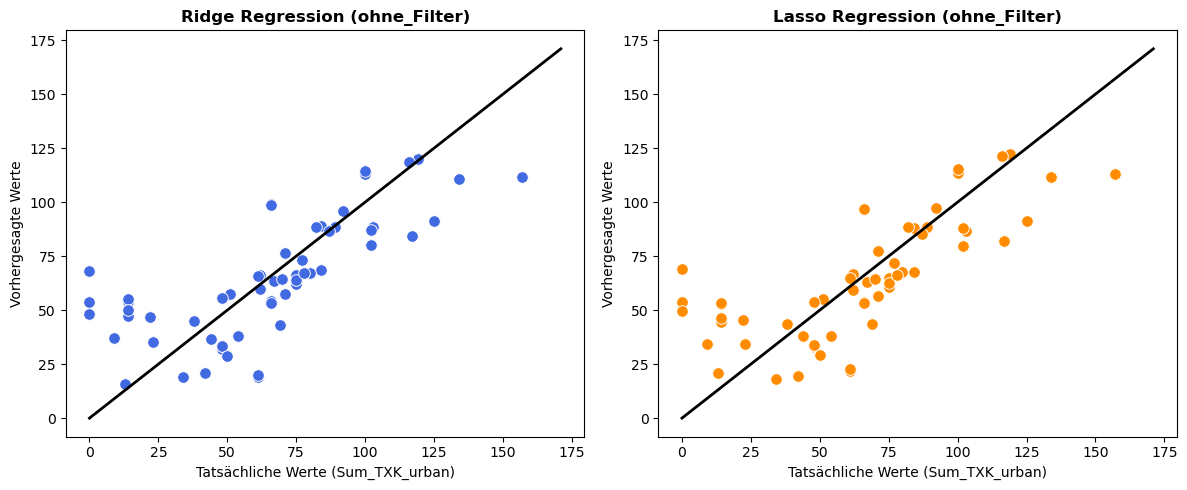


=== Wichtigste Features laut Lasso (Top 15) – ohne_Filter ===
mean_MO_TT^2                         37.362
mean_MO_RR station_height            13.215
mean_MO_FK^2                          7.320
mean_MO_TT mean_MO_SD_S               1.780
population_density mean_MO_FK         1.217
population_density^2                 -0.107
population_density station_height    -0.161
mean_MO_SD_S station_height          -2.656
station_height^2                     -3.233
mean_MO_FK station_height            -5.471
mean_MO_RR lat                      -11.933
mean_MO_TT mean_MO_FK               -13.173
mean_MO_TT lat                      -15.052
dtype: float64

=== Ridge & Lasso Regression – mit_Filter ===
Anzahl der Städte: 247
=== Cross-Validation (5-fold) Ergebnisse ===
             Modell  R² (mean)  R² (std)  RMSE (mean)  RMSE (std)  MAE (mean)  \
0  Ridge Regression      0.797     0.030       13.101       0.733       9.860   
1  Lasso Regression      0.792     0.023       13.291       0.800       9

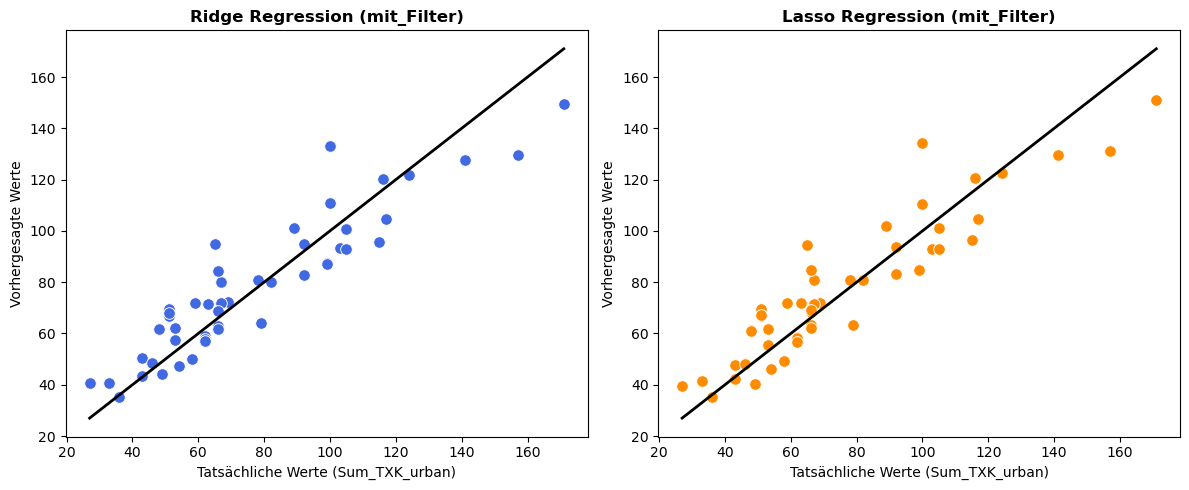


=== Wichtigste Features laut Lasso (Top 15) – mit_Filter ===
mean_MO_TT^2                         14.606
population_density mean_MO_RR         5.001
population_density^2                  3.452
mean_MO_TT mean_MO_SD_S               1.620
mean_MO_FK mean_MO_SD_S               0.766
mean_MO_FK^2                          0.636
mean_MO_RR^2                          0.265
mean_MO_RR station_height             0.139
station_height^2                     -2.469
population_density station_height    -3.113
mean_MO_SD_S station_height          -5.032
mean_MO_FK mean_MO_RR                -5.256
population_density mean_MO_FK        -7.643
lat                                 -15.485
dtype: float64


In [ ]:
# ================================================================
# Ridge & Lasso Regression – Vergleich auf polynomialen Features (mit & ohne Filter)
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------------------------
# 1) Daten laden und vorbereiten
# -------------------------------------------------
file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"
df_full = pd.read_excel(file_path)

features = [
    "population", "area_km2", "mean_MO_TT", "mean_MO_FK",
    "mean_MO_SD_S", "mean_MO_RR", "lat", "station_height"
]
target = "Sum_TXK_urban"

df_full = df_full[features + [target]].dropna()
df_full["population_density"] = df_full["population"] / df_full["area_km2"]

# Zwei Varianten des Datensatzes
datasets = {
    "ohne_Filter": df_full,
    "mit_Filter": df_full[df_full["Sum_TXK_urban"] > 25]
}

# -------------------------------------------------
# 2) Modelle & Scoring definieren
# -------------------------------------------------
scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

models = {
    "Ridge Regression": Ridge(alpha=10, random_state=42),
    "Lasso Regression": Lasso(alpha=0.1, random_state=42, max_iter=10000)
}

# -------------------------------------------------
# 3) Cross-Validation & Visualisierung für beide Varianten
# -------------------------------------------------
for name, df in datasets.items():
    print(f"\n=== Ridge & Lasso Regression – {name} ===")
    print(f"Anzahl der Städte: {len(df)}")

    X = df[[
        "population_density", "mean_MO_TT", "mean_MO_FK",
        "mean_MO_SD_S", "mean_MO_RR", "lat", "station_height"
    ]]
    y = df[target]

    results_list = []

    for model_name, model in models.items():
        pipeline = make_pipeline(
            PolynomialFeatures(degree=2, include_bias=False),
            StandardScaler(),
            model
        )

        cv_results = cross_validate(pipeline, X, y, cv=5, scoring=scoring)

        r2_mean = np.mean(cv_results["test_r2"])
        r2_std = np.std(cv_results["test_r2"])
        rmse_scores = -cv_results["test_rmse"]
        mae_scores = -cv_results["test_mae"]

        results_list.append({
            "Modell": model_name,
            "R² (mean)": r2_mean,
            "R² (std)": r2_std,
            "RMSE (mean)": rmse_scores.mean(),
            "RMSE (std)": rmse_scores.std(),
            "MAE (mean)": mae_scores.mean(),
            "MAE (std)": mae_scores.std()
        })

    results_df = pd.DataFrame(results_list).round(3)
    print("=== Cross-Validation (5-fold) Ergebnisse ===")
    print(results_df)

    # -------------------------------------------------
    # 4) Train/Test Split zur Visualisierung
    # -------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_test_scaled = scaler.transform(X_test_poly)

    ridge = Ridge(alpha=10, random_state=42)
    lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
    ridge.fit(X_train_scaled, y_train)
    lasso.fit(X_train_scaled, y_train)

    y_pred_ridge = ridge.predict(X_test_scaled)
    y_pred_lasso = lasso.predict(X_test_scaled)

    # -------------------------------------------------
    # 5) Visualisierung: Ist vs. Prognose
    # -------------------------------------------------
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_test, y=y_pred_ridge, color="royalblue", s=70)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], color="black", lw=2)
    plt.title(f"Ridge Regression ({name})", fontsize=12, weight="bold")
    plt.xlabel("Tatsächliche Werte (Sum_TXK_urban)")
    plt.ylabel("Vorhergesagte Werte")

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_test, y=y_pred_lasso, color="darkorange", s=70)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], color="black", lw=2)
    plt.title(f"Lasso Regression ({name})", fontsize=12, weight="bold")
    plt.xlabel("Tatsächliche Werte (Sum_TXK_urban)")
    plt.ylabel("Vorhergesagte Werte")

    plt.tight_layout()
    save_path = directory_images + fr"\ridge_lasso_comparison_cv_{name}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    # -------------------------------------------------
    # 6) Wichtigste Features laut Lasso (Top 15)
    # -------------------------------------------------
    feature_names = poly.get_feature_names_out(X.columns)
    lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

    important_features = (
        lasso_coefs[lasso_coefs.abs() > 0.1]
        .sort_values(ascending=False)
        .head(15)
    )

    print(f"\n=== Wichtigste Features laut Lasso (Top 15) – {name} ===")
    print(important_features.round(3))


Nach Filterung verbleibende Städte: 247
=== Cross-Validation (5-fold): Elastic Net Regression ===
R² (Durchschnitt):   0.785 ± 0.039
RMSE (Durchschnitt):  13.435 ± 0.949
MAE (Durchschnitt):   10.022 ± 0.826


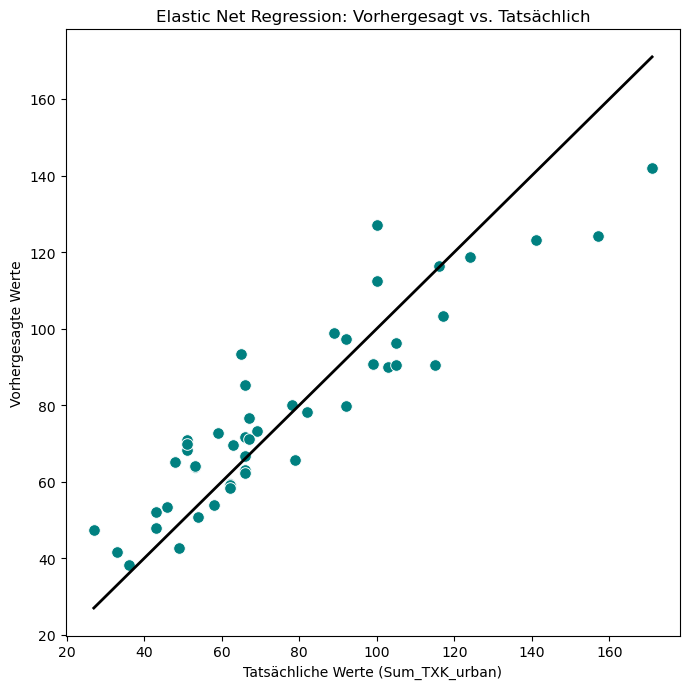

In [ ]:
# ======================
# Elastic Net Regression 
# ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------------------------
# 1) Daten laden und vorbereiten
# -------------------------------------------------
file_path = directory + r"\bereinigte_DS_Tabelle_V2.xlsx"
df = pd.read_excel(file_path)

features = [
    "population", "area_km2", "mean_MO_TT", "mean_MO_FK",
    "mean_MO_SD_S", "mean_MO_RR", "lat", "station_height"
]
target = "Sum_TXK_urban"

df = df[features + [target]].dropna()
df["population_density"] = df["population"] / df["area_km2"]

# Filter anwenden
df = df[df["Sum_TXK_urban"] > 25]
print(f"Nach Filterung verbleibende Städte: {len(df)}")

X = df[[
    "population_density", "mean_MO_TT", "mean_MO_FK",
    "mean_MO_SD_S", "mean_MO_RR", "lat", "station_height"
]]
y = df[target]

# -------------------------------------------------
# 2) Cross-Validation Setup
# -------------------------------------------------
scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

# Elastic Net mit mittlerer Mischung aus Ridge (L2) und Lasso (L1)
elastic_net = ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=42, max_iter=10000)

# Pipeline: Polynome + Skalierung + Modell
pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    elastic_net
)

# Cross-Validation
cv_results = cross_validate(pipeline, X, y, cv=5, scoring=scoring)

# Ergebnisse berechnen
r2_mean = np.mean(cv_results["test_r2"])
r2_std = np.std(cv_results["test_r2"])
rmse_scores = -cv_results["test_rmse"]
mae_scores = -cv_results["test_mae"]

print("=== Cross-Validation (5-fold): Elastic Net Regression ===")
print(f"R² (Durchschnitt):   {r2_mean:.3f} ± {r2_std:.3f}")
print(f"RMSE (Durchschnitt):  {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}")
print(f"MAE (Durchschnitt):   {mae_scores.mean():.3f} ± {mae_scores.std():.3f}")

# -------------------------------------------------
# 3) Train/Test Split für Visualisierung
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

elastic_net.fit(X_train_scaled, y_train)
y_pred = elastic_net.predict(X_test_scaled)

# -------------------------------------------------
# 4) Visualisierung: Ist vs. Prognose
# -------------------------------------------------
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred, s=70, color="teal")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="black", lw=2)
plt.title("Elastic Net Regression: Vorhergesagt vs. Tatsächlich")
plt.xlabel("Tatsächliche Werte (Sum_TXK_urban)")
plt.ylabel("Vorhergesagte Werte")
plt.tight_layout()
plt.savefig(directory_images + r"\elastic_net_regression_cv.png", dpi=300, bbox_inches="tight")
plt.show()
